# WMH MedSAM-LoRA: Frozen / Rank-4 / Rank-8 Ablations

Separate ablation notebook derived from the supplied clean v1.0.0 reproduction.
The original notebook is not modified. Run cells in order in the same CUDA
Colab environment with the original prepared data, CSVs, base weights and MedSAM
source. Restart the runtime before switching experiments, then change only
`ABLATION_MODE` in code cell 01 and run all cells.

| Mode | LoRA rank | Injected layers | Trainable parameters | Total parameters |
|---|---:|---:|---:|---:|
| `frozen` | 0 (disabled) | 0 | 0 | 93,735,472 |
| `lora_r4` (default) | 4 | 80 | 673,792 | 94,409,264 |
| `lora_r8` | 8 | 80 | 1,347,584 | 95,083,056 |

Rank 4 preserves the source's custom LoRA class, initialization order, targets,
unscaled residual, loss, optimizer, AMP, gradient verification and training
operations. Rank 8 changes only the adapter rank. No PEFT or new architecture
is introduced. All modes start from the same base MedSAM checkpoint, not a
previously fine-tuned LoRA checkpoint.

**Frozen semantics:** with no trainable parameters, optimization is impossible.
The same 20-epoch schedule still traverses the same shuffled training loader,
computes the same AMP loss, validates with the unchanged function, and saves the
same checkpoint/history formats. Frozen train passes use `eval()` and
`no_grad()`; no optimizer, backward pass or scaler step is attempted. Weights and
buffers are fingerprinted before and after the run to verify they remain fixed.
`train_loss` in this mode means loss measured on the training cohort, not learning.
Validation selection keeps the original strict `>` rule; ties keep the first best.

**Preserved protocols:** patient split and all slices; min–max/RGB/1024² image
preprocessing; raw nearest-resized masks and GT boxes; batch size 2; 20 epochs;
AdamW lr=1e-4/weight_decay=1e-4 for LoRA; original validation and all three test
metric paths. Raw-label behavior, empty-mask conventions, and historical
batch-mean vs binary per-slice reporting are retained, including their limitations.

Outputs default to `PROJECT_DIR/results/ablation/<ABLATION_MODE>/`, with the
original `configs`, `checkpoints`, `logs`, and `evaluation` subdirectories,
filenames and CSV columns. Checkpoint filenames retain `lora` even for `frozen`
for format compatibility; the containing directory and metadata identify the mode.
Existing outputs are never silently overwritten. For a repeat run, set a new
`RUN_TAG`; it creates a subdirectory within that mode's folder.

`RUN_MODE='train_fresh'` runs the selected ablation. The existing
`evaluate_final` functionality remains available only for rank 4 and retains its
historical checkpoint checks. `evaluate_ablation` reloads a completed ablation
checkpoint without training; set `ABLATION_CHECKPOINT` to that file and use a
fresh `RUN_TAG` (for example `eval_001`). Strict mode/rank/base/split checks
prevent accidentally evaluating a checkpoint from another experiment.

Historical reference comparisons are retained as contextual output; they are
not claimed as the expected performance of frozen or rank-8 experiments. No new
training or test results are embedded in this notebook.

This notebook contains the completed ablation analysis after executing
Frozen, LoRA rank-4 and LoRA rank-8 runs separately.
The final analysis section reads saved run artifacts and does not perform training.


# WMH MedSAM LoRA Ablation Study

This notebook contains the final ablation analysis for:
- Frozen MedSAM
- LoRA rank-4
- LoRA rank-8

The training runs were executed separately and the final evaluation artifacts are loaded for reproducible comparison.

### Code cell 01 — Configuration — paths and execution mode


In [36]:
from pathlib import Path

ABLATION_MODE = "frozen"  # "frozen", "lora_r4", or "lora_r8"

ABLATION_SPECS = {
    'frozen': {
        'rank': 0,
        'layers': 0,
        'trainable': 0,
        'total': 93735472
    },
    'lora_r4': {
        'rank': 4,
        'layers': 80,
        'trainable': 673792,
        'total': 94409264
    },
    'lora_r8': {
        'rank': 8,
        'layers': 80,
        'trainable': 1347584,
        'total': 95083056
    },
}

if ABLATION_MODE not in ABLATION_SPECS:
    raise ValueError(f'Unsupported ABLATION_MODE: {ABLATION_MODE}')

ABLATION_SPEC = ABLATION_SPECS[ABLATION_MODE]

LORA_ENABLED = ABLATION_MODE != 'frozen'
LORA_RANK = ABLATION_SPEC['rank']

RUN_MODE = 'train_fresh'  # 'train_fresh', 'evaluate_final', or 'evaluate_ablation'

SEED = 42
STRICT_DETERMINISM = True

EXPECTED_BASE_SHA256 = None
EXPECTED_HISTORICAL_SHA256 = None
EXPECTED_SPLIT_SHA256 = {}

EXPECTED_DATA_SHA256_JSON = None

BATCH_SIZE = 2
NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


# New run directory to keep previous run intact
RUN_TAG = "a100_frozen_run004"

PROJECT_DIR = Path('/content/drive/MyDrive/WMH_MedSAM_Project')

SPLIT_DIR = PROJECT_DIR / 'manifests'
WMH_ROOT = PROJECT_DIR / 'data/wmh_dataset/wmh_data'

BASE_CHECKPOINT = PROJECT_DIR / 'checkpoints/medsam_vit_b.pth'

HISTORICAL_CHECKPOINT = PROJECT_DIR / 'checkpoints/best_lora_wmh.pth'
RUN_DIR = PROJECT_DIR / 'results' / 'ablation' / ABLATION_MODE / RUN_TAG

print("RUN_TAG:", RUN_TAG)
print("RUN_DIR:", RUN_DIR)

RUN_TAG: a100_frozen_run004
RUN_DIR: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004


### Code cell 02 — Mount Drive when running in Colab


In [37]:
try:
    from google.colab import drive
except ImportError:
    print('Standard Jupyter runtime: use the local paths configured in cell 01.')
else:
    drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Code cell 03 — Use the supplied dependency environment and MedSAM source


In [38]:
# ============================================================
# Cell 03 — MedSAM source setup
# ============================================================

from pathlib import Path
import sys
import os
import subprocess


# ------------------------------------------------------------
# MedSAM source location
# ------------------------------------------------------------

MEDSAM_SOURCE_DIR = Path("/content/MedSAM")


# ------------------------------------------------------------
# Clone MedSAM repository if missing
# ------------------------------------------------------------

if not MEDSAM_SOURCE_DIR.exists():

    print("MedSAM source not found.")
    print("Cloning official MedSAM repository...")

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/bowang-lab/MedSAM.git",
            str(MEDSAM_SOURCE_DIR)
        ],
        check=True
    )

else:

    print("Existing MedSAM source found.")


# ------------------------------------------------------------
# Add MedSAM to Python path
# ------------------------------------------------------------

if str(MEDSAM_SOURCE_DIR) not in sys.path:

    sys.path.append(
        str(MEDSAM_SOURCE_DIR)
    )


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("\nMedSAM source:")
print(MEDSAM_SOURCE_DIR)

print("\nExists:", MEDSAM_SOURCE_DIR.exists())

print("\nPython path updated:")
print(str(MEDSAM_SOURCE_DIR) in sys.path)

Existing MedSAM source found.

MedSAM source:
/content/MedSAM

Exists: True

Python path updated:
True


### Code cell 04 — Imports, CUDA and repeatable fresh-run initialization


In [39]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import hashlib
import inspect
import json
import random
import platform
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, default_collate
from tqdm.auto import tqdm
from IPython.display import display
from segment_anything import sam_model_registry
import segment_anything

if not torch.cuda.is_available():
    raise RuntimeError('Final uses CUDA AMP. Select a CUDA GPU runtime; no CPU substitute is used.')
device = torch.device('cuda', torch.cuda.current_device())
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = STRICT_DETERMINISM
torch.use_deterministic_algorithms(STRICT_DETERMINISM)

if not Path(segment_anything.__file__).resolve().is_relative_to(MEDSAM_SOURCE_DIR.resolve()):
    raise RuntimeError('segment_anything was imported from the wrong source directory.')
if RUN_DIR.exists() and any(RUN_DIR.iterdir()):
    raise FileExistsError('RUN_DIR is not empty. Set a new RUN_TAG in cell 01; keep completed runs intact.')
CONFIG_DIR = RUN_DIR / 'configs'
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'
LOG_DIR = RUN_DIR / 'logs'
EVAL_DIR = RUN_DIR / 'evaluation'
for folder in [CONFIG_DIR, CHECKPOINT_DIR, LOG_DIR, EVAL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

print('GPU:', torch.cuda.get_device_name(device))
print('torch:', torch.__version__, 'CUDA build:', torch.version.cuda)
print('Seed:', SEED, 'strict deterministic algorithms:', STRICT_DETERMINISM)
print('Outputs:', RUN_DIR)


GPU: NVIDIA A100-SXM4-40GB
torch: 2.11.0+cu128 CUDA build: 12.8
Seed: 42 strict deterministic algorithms: True
Outputs: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004


## Reproducibility notes

Deterministic settings are enabled for reproducible fresh runs.
Minor differences may still occur due to CUDA/library versions.

### Code cell 05 — Load original split files without resplitting or sorting


In [40]:
split_specs = {'train': (42, 14), 'val': (9, 3), 'test': (9, 3)}
split_hashes, splits = {}, {}
required_columns = {'patient_id', 'site', 'image_path', 'mask_path'}
for name, (n_patients, n_per_site) in split_specs.items():
    path = SPLIT_DIR / f'{name}.csv'
    if not path.is_file():
        raise FileNotFoundError(
            f'Missing original Final split: {path}. Do not generate a replacement split.')
    split_hashes[name] = sha256_file(path)
    if name in EXPECTED_SPLIT_SHA256:
        assert split_hashes[name] == EXPECTED_SPLIT_SHA256[name], name
    df = pd.read_csv(path)  # same reading behavior and CSV row order as Final F114
    assert required_columns.issubset(df.columns), name
    assert len(df) == n_patients and not df['patient_id'].isna().any(), name
    assert not df.duplicated(['site', 'patient_id']).any(), name
    assert df['site'].value_counts().to_dict() == dict.fromkeys(
        ['Amsterdam', 'Singapore', 'Utrecht'], n_per_site), name
    splits[name] = df
    (CONFIG_DIR / f'original_{name}.csv').write_bytes(path.read_bytes())

def patient_keys(df):
    return set(zip(df['site'], df['patient_id'].astype(str)))

train_df, val_df, test_df = (splits[name] for name in ['train', 'val', 'test'])
train_keys, val_keys, test_keys = map(patient_keys, [train_df, val_df, test_df])
assert not (train_keys & val_keys or train_keys & test_keys or val_keys & test_keys)
assert len(train_keys | val_keys | test_keys) == 60

# Exact partial/full identity evidence visible in Final F114 and F153–154.
# These checks supplement, and do not replace, the ORIGINAL CSV requirement.
assert train_df['patient_id'].astype(str).head(5).tolist() == ['27', '31', '101', '55', '64']
assert test_keys == {
    ('Amsterdam', '112'), ('Amsterdam', '116'), ('Amsterdam', '137'),
    ('Singapore', '60'), ('Singapore', '65'), ('Singapore', '66'),
    ('Utrecht', '21'), ('Utrecht', '23'), ('Utrecht', '49'),
}
assert str(test_df.iloc[0]['patient_id']) == '60'
(CONFIG_DIR / 'split_sha256.json').write_text(json.dumps(split_hashes, indent=2))
for name, df in splits.items():
    print(name, 'patient IDs in execution order:', list(zip(df['site'], df['patient_id'])))


train patient IDs in execution order: [('Utrecht', 27), ('Utrecht', 31), ('Amsterdam', 101), ('Singapore', 55), ('Singapore', 64), ('Utrecht', 17), ('Singapore', 53), ('Amsterdam', 105), ('Amsterdam', 132), ('Amsterdam', 115), ('Singapore', 56), ('Utrecht', 0), ('Amsterdam', 104), ('Utrecht', 2), ('Singapore', 58), ('Amsterdam', 109), ('Singapore', 51), ('Utrecht', 37), ('Amsterdam', 113), ('Utrecht', 41), ('Singapore', 57), ('Singapore', 52), ('Singapore', 59), ('Amsterdam', 102), ('Singapore', 61), ('Singapore', 63), ('Utrecht', 33), ('Utrecht', 6), ('Amsterdam', 108), ('Utrecht', 19), ('Amsterdam', 106), ('Singapore', 67), ('Singapore', 69), ('Utrecht', 8), ('Utrecht', 39), ('Amsterdam', 114), ('Amsterdam', 103), ('Amsterdam', 126), ('Utrecht', 25), ('Singapore', 54), ('Amsterdam', 100), ('Utrecht', 29)]
val patient IDs in execution order: [('Amsterdam', 144), ('Utrecht', 35), ('Singapore', 68), ('Amsterdam', 110), ('Singapore', 62), ('Singapore', 50), ('Amsterdam', 107), ('Utrecht'

### Code cell 06 — Resolve the same patients to the prepared WMH files


In [41]:
TRAIN_ROOT = WMH_ROOT / 'training'
if not TRAIN_ROOT.is_dir():
    raise FileNotFoundError(f'Provide the original prepared WMH data: {TRAIN_ROOT}')
path_lookup = {}
for site in ['Amsterdam', 'Singapore', 'Utrecht']:
    for mask_path in (TRAIN_ROOT / site).rglob('wmh.nii'):
        patient_dir = mask_path.parent
        key = (site, patient_dir.name)
        flair_path = patient_dir / 'pre/FLAIR.nii'
        if not flair_path.is_file():
            raise FileNotFoundError(flair_path)
        if key in path_lookup:
            raise ValueError(f'Ambiguous patient directory: {key}')
        path_lookup[key] = (str(flair_path), str(mask_path))
assert set(path_lookup) == train_keys | val_keys | test_keys

def resolve_split_paths(df):
    result = df.copy()
    paths = [path_lookup[(row.site, str(row.patient_id))]
             for row in result.itertuples(index=False)]
    result['image_path'] = [p[0] for p in paths]
    result['mask_path'] = [p[1] for p in paths]
    return result  # preserves row order and every patient identity

train_df, val_df, test_df = map(resolve_split_paths, [train_df, val_df, test_df])
splits = {'train': train_df, 'val': val_df, 'test': test_df}
for name, df in splits.items():
    df.to_csv(CONFIG_DIR / f'{name}_resolved.csv', index=False)
print('Resolved 60 unique original patients, including Amsterdam/GE3T nesting.')


Resolved 60 unique original patients, including Amsterdam/GE3T nesting.


### Code cell 07 — Input audit — preserve raw masks and record file identities


In [42]:
audit_rows, input_hashes = [], {}
for name, df in splits.items():
    for row in tqdm(df.itertuples(index=False), total=len(df), desc=f'Audit {name}'):
        image = nib.load(row.image_path).get_fdata()
        mask = nib.load(row.mask_path).get_fdata()
        assert image.ndim == 3 and image.shape == mask.shape
        assert np.isfinite(image).all() and np.isfinite(mask).all()
        labels = np.unique(mask).tolist()
        audit_rows.append({
            'split': name, 'site': row.site, 'patient_id': str(row.patient_id),
            'shape': list(image.shape), 'mask_values': labels,
            'slices': image.shape[2],
            'positive_slices_raw_sum': int((mask.sum(axis=(0, 1)) > 0).sum()),
        })
        for kind, path in [('image', row.image_path), ('mask', row.mask_path)]:
            input_hashes[f'{row.site}/{row.patient_id}/{kind}'] = sha256_file(path)

if EXPECTED_DATA_SHA256_JSON is not None:
    assert input_hashes == json.loads(Path(EXPECTED_DATA_SHA256_JSON).read_text())
(CONFIG_DIR / 'input_sha256.json').write_text(json.dumps(input_hashes, indent=2))
(CONFIG_DIR / 'data_audit.json').write_text(json.dumps(audit_rows, indent=2))
for name, expected in [('train', (2506, 987)), ('val', (537, 221)), ('test', (537, 232))]:
    rows = [r for r in audit_rows if r['split'] == name]
    actual = (sum(r['slices'] for r in rows), sum(r['positive_slices_raw_sum'] for r in rows))
    assert actual == expected, (name, actual, expected)
    print(name, 'all / positive / empty:', actual[0], actual[1], actual[0] - actual[1])

nonbinary = [r for r in audit_rows if not set(r['mask_values']).issubset({0.0, 1.0})]
print('Volumes with nonbinary mask labels:', len(nonbinary))
if nonbinary:
    print('Raw targets retained to reproduce Final; binary loss/metric validity needs separate review.')
    print([(r['site'], r['patient_id'], r['mask_values']) for r in nonbinary])
del image, mask


Audit train:   0%|          | 0/42 [00:00<?, ?it/s]

Audit val:   0%|          | 0/9 [00:00<?, ?it/s]

Audit test:   0%|          | 0/9 [00:00<?, ?it/s]

train all / positive / empty: 2506 987 1519
val all / positive / empty: 537 221 316
test all / positive / empty: 537 232 305
Volumes with nonbinary mask labels: 25
Raw targets retained to reproduce Final; binary loss/metric validity needs separate review.
[('Utrecht', '27', [0.0, 1.0, 2.0]), ('Singapore', '64', [0.0, 1.0, 2.0]), ('Utrecht', '17', [0.0, 1.0, 2.0]), ('Amsterdam', '105', [0.0, 1.0, 2.0]), ('Utrecht', '0', [0.0, 1.0, 2.0]), ('Amsterdam', '104', [0.0, 1.0, 2.0]), ('Singapore', '51', [0.0, 1.0, 2.0]), ('Amsterdam', '113', [0.0, 1.0, 2.0]), ('Utrecht', '41', [0.0, 1.0, 2.0]), ('Singapore', '59', [0.0, 1.0, 2.0]), ('Singapore', '61', [0.0, 1.0, 2.0]), ('Singapore', '63', [0.0, 1.0, 2.0]), ('Amsterdam', '108', [0.0, 1.0, 2.0]), ('Utrecht', '19', [0.0, 1.0, 2.0]), ('Singapore', '67', [0.0, 1.0, 2.0]), ('Utrecht', '25', [0.0, 1.0, 2.0]), ('Singapore', '54', [0.0, 1.0, 2.0]), ('Utrecht', '29', [0.0, 1.0, 2.0]), ('Singapore', '68', [0.0, 1.0, 2.0]), ('Singapore', '62', [0.0, 1.0, 2

### Code cell 08 — Dataset — exact Final F124 definition


In [43]:
class WMHMedSAMDataset(Dataset):

    def __init__(self, df):
        self.samples = []
        for _, row in tqdm(df.iterrows(), total=len(df)):
            flair = nib.load(row['image_path']).get_fdata()
            for z in range(flair.shape[2]):
                self.samples.append({'image_path': row['image_path'], 'mask_path': row['mask_path'], 'slice_id': z, 'patient_id': row['patient_id'], 'site': row['site']})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        flair = nib.load(item['image_path']).get_fdata()
        mask = nib.load(item['mask_path']).get_fdata()
        z = item['slice_id']
        image = flair[:, :, z]
        mask = mask[:, :, z]
        image = (image - image.min()) / (image.max() - image.min() + 1e-08)
        image = np.stack([image, image, image], axis=-1)
        image = cv2.resize(image, (1024, 1024), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask.astype(np.float32), (1024, 1024), interpolation=cv2.INTER_NEAREST)
        ys, xs = np.where(mask > 0)
        if len(xs) > 0:
            box = np.array([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.float32)
        else:
            box = np.array([0, 0, 0, 0], dtype=np.float32)
        image = torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        box = torch.tensor(box, dtype=torch.float32)
        return {'image': image, 'mask': mask, 'box': box, 'patient_id': item['patient_id'], 'site': item['site'], 'slice_id': item['slice_id']}


### Code cell 09 — Build datasets and verify slices, tensor shapes and empty boxes


In [44]:
train_dataset = WMHMedSAMDataset(train_df)
val_dataset = WMHMedSAMDataset(val_df)
test_dataset = WMHMedSAMDataset(test_df)
assert tuple(map(len, [train_dataset, val_dataset, test_dataset])) == (2506, 537, 537)

verification = {'patients': [42, 9, 9], 'slices': [2506, 537, 537]}
for name, dataset in [('train', train_dataset), ('val', val_dataset), ('test', test_dataset)]:
    sample = dataset[0]  # deterministic indexing; no shuffled-loader RNG draw
    assert sample['image'].shape == (3, 1024, 1024)
    assert sample['mask'].shape == (1024, 1024)
    assert sample['box'].shape == (4,)
    assert all(sample[k].dtype == torch.float32 for k in ['image', 'mask', 'box'])
    assert torch.equal(sample['image'][0], sample['image'][1])
    assert torch.equal(sample['image'][1], sample['image'][2])
    assert sample['image'].min() >= 0 and sample['image'].max() <= 1
    if not (sample['mask'] > 0).any():
        assert torch.equal(sample['box'], torch.zeros(4))
    print(name, len(dataset), sample['image'].shape, sample['mask'].shape, sample['box'].tolist())

# Verify index ordering against the original split dataframes.
for df, dataset in [(train_df, train_dataset), (val_df, val_dataset), (test_df, test_dataset)]:
    expected_index = []
    for row in df.itertuples(index=False):
        depth = nib.load(row.image_path).shape[2]
        expected_index.extend((row.site, str(row.patient_id), z) for z in range(depth))
    actual_index = [(s['site'], str(s['patient_id']), s['slice_id']) for s in dataset.samples]
    assert actual_index == expected_index
verification['image_shape'] = [3, 1024, 1024]
verification['mask_shape'] = [1024, 1024]
verification['box_shape'] = [4]


  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

train 2506 torch.Size([3, 1024, 1024]) torch.Size([1024, 1024]) [0.0, 0.0, 0.0, 0.0]
val 537 torch.Size([3, 1024, 1024]) torch.Size([1024, 1024]) [0.0, 0.0, 0.0, 0.0]
test 537 torch.Size([3, 1024, 1024]) torch.Size([1024, 1024]) [0.0, 0.0, 0.0, 0.0]


### Code cell 10 — DataLoaders — Final F126 batch/worker/shuffle settings


In [45]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
assert tuple(map(len, [train_loader, val_loader, test_loader])) == (1253, 269, 269)
assert all(not loader.drop_last for loader in [train_loader, val_loader, test_loader])
verification['batches'] = [1253, 269, 269]
print('Batches:', verification['batches'], '; validation/test retain the final single slice.')


Batches: [1253, 269, 269] ; validation/test retain the final single slice.


### Code cell 11 — Load original MedSAM ViT-B base checkpoint


In [46]:
if not BASE_CHECKPOINT.is_file():
    raise FileNotFoundError(BASE_CHECKPOINT)
base_sha256 = sha256_file(BASE_CHECKPOINT)
if EXPECTED_BASE_SHA256 is not None:
    assert base_sha256 == EXPECTED_BASE_SHA256
sam = sam_model_registry['vit_b'](checkpoint=str(BASE_CHECKPOINT))
sam.to(device)
print('SAM class:', type(sam).__module__, type(sam).__qualname__)
print('Base checkpoint SHA256:', base_sha256)


SAM class: segment_anything.modeling.sam Sam
Base checkpoint SHA256: 34b34b78c1d18cb8c6bf84cf9c00e135d6d6c965699f3c0e31ef1bc9dcb5be74


### Code cell 12 — Custom LoRA — original LoRALinear; rank passed through the same injector


In [47]:
class LoRALinear(nn.Module):

    def __init__(self, original_layer, rank=4):
        super().__init__()
        self.original = original_layer
        for p in self.original.parameters():
            p.requires_grad = False
        self.lora_A = nn.Linear(original_layer.in_features, rank, bias=False)
        self.lora_B = nn.Linear(rank, original_layer.out_features, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=5 ** 0.5)
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.original(x) + self.lora_B(self.lora_A(x))

def add_lora_controlled(model, rank=4):
    count = 0
    targets = ['image_encoder.blocks', 'mask_decoder.transformer.layers', 'mask_decoder.transformer.final_attn_token_to_image']
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any((t in name for t in targets)):
                parent = model
                parts = name.split('.')
                for p in parts[:-1]:
                    parent = getattr(parent, p)
                setattr(parent, parts[-1], LoRALinear(module, rank=rank))
                count += 1
    return count


### Code cell 13 — Inject once; freeze backbone; verify targets/rank/parameter counts


In [48]:
if any(isinstance(module, LoRALinear) for module in sam.modules()):
    raise RuntimeError('Model already contains LoRA. Reload the base model before reinjection.')
lora_count = add_lora_controlled(sam, rank=LORA_RANK) if LORA_ENABLED else 0
for name, param in sam.named_parameters():
    param.requires_grad = LORA_ENABLED and ('lora_' in name)
sam.to(device)  # adapters were constructed on CPU; move them before the optimizer

adapters = [(name, module) for name, module in sam.named_modules() if isinstance(module, LoRALinear)]
assert lora_count == len(adapters) == ABLATION_SPEC['layers']
if LORA_ENABLED:
    assert sum(name.startswith('image_encoder.blocks.') for name, _ in adapters) == 48
    assert sum(name.startswith('mask_decoder.transformer.layers.') for name, _ in adapters) == 28
    assert sum(name.startswith('mask_decoder.transformer.final_attn_token_to_image.') for name, _ in adapters) == 4
else:
    assert not adapters and not any(p.requires_grad for p in sam.parameters())
for name, adapter in adapters:
    assert adapter.lora_A.out_features == adapter.lora_B.in_features == LORA_RANK, name
    assert adapter.lora_A.bias is None and adapter.lora_B.bias is None
    assert torch.count_nonzero(adapter.lora_B.weight).item() == 0
    assert not hasattr(adapter, 'scaling') and not hasattr(adapter, 'alpha')

trainable_params = [p for p in sam.parameters() if p.requires_grad]
trainable_count = sum(p.numel() for p in trainable_params)
total_count = sum(p.numel() for p in sam.parameters())
assert (trainable_count, total_count, len(trainable_params)) == (ABLATION_SPEC['trainable'], ABLATION_SPEC['total'], 160 if LORA_ENABLED else 0)
assert all(p.device == device for p in sam.parameters())
assert all(p.requires_grad == (LORA_ENABLED and ('lora_' in name)) for name, p in sam.named_parameters())
verification.update(ablation_mode=ABLATION_MODE, lora_enabled=LORA_ENABLED,
                    lora_layers=lora_count, rank=LORA_RANK, residual_multiplier=1 if LORA_ENABLED else 0,
                    trainable_parameters=trainable_count, total_parameters=total_count)
(CONFIG_DIR / 'lora_targets.json').write_text(json.dumps([name for name, _ in adapters], indent=2))
print('Selected ablation mode:', ABLATION_MODE)
print('LoRA:', 'enabled' if LORA_ENABLED else 'disabled')
print('Rank:', LORA_RANK, '; injected layers:', lora_count)
print('Trainable parameters:', trainable_count)
print('Total parameters:', total_count)

def model_state_sha256(model):
    # Used only for frozen-state verification; includes every parameter and buffer.
    digest = hashlib.sha256()
    for name, value in model.state_dict().items():
        tensor = value.detach().cpu().contiguous()
        digest.update(str((name, str(tensor.dtype), tuple(tensor.shape))).encode())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()

frozen_initial_sha256 = model_state_sha256(sam) if not LORA_ENABLED else None


Selected ablation mode: frozen
LoRA: disabled
Rank: 0 ; injected layers: 0
Trainable parameters: 0
Total parameters: 93735472


### Code cell 14 — Original AdamW, exact F128 loss, and AMP scaler


In [49]:
optimizer = None
if LORA_ENABLED:
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, sam.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )


class DiceBCELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        pred = torch.sigmoid(pred)
        smooth = 1e-05
        intersection = (pred * target).sum()
        dice = (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        dice_loss = 1 - dice
        return bce_loss + dice_loss

loss_fn = DiceBCELoss()
scaler = torch.amp.GradScaler('cuda') if LORA_ENABLED else None
print('AdamW lr=1e-4, weight_decay=1e-4' if LORA_ENABLED else
      'Frozen: no optimizer or backward/scaler step; forward-only training-cohort passes.')
print('Unchanged loss: mean BCE + batch-global soft Dice (smooth=1e-5).')


Frozen: no optimizer or backward/scaler step; forward-only training-cohort passes.
Unchanged loss: mean BCE + batch-global soft Dice (smooth=1e-5).


### Code cell 15 — Direct differentiable forward — same operations as F138


In [50]:
def forward_logits(model, image, box):
    # No model.preprocess, SamPredictor, detach, sigmoid, or no_grad here.
    image_embeddings = model.image_encoder(image)
    sparse_embeddings, dense_embeddings = model.prompt_encoder(
        points=None, boxes=box, masks=None,
    )
    low_res_masks, _ = model.mask_decoder(
        image_embeddings=image_embeddings,
        image_pe=model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )
    assert image_embeddings.shape == (image.shape[0], 256, 64, 64)
    assert low_res_masks.shape == (image.shape[0], 1, 256, 256)
    pred_mask = F.interpolate(
        low_res_masks, size=(1024, 1024), mode='bilinear', align_corners=False,
    )
    return pred_mask.squeeze(1)


### Code cell 16 — Exact validation and test metric definitions from Final


In [51]:
def calculate_metrics(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    dice = (2 * intersection + 1e-05) / (pred.sum() + target.sum() + 1e-05)
    union = (pred + target - pred * target).sum()
    iou = (intersection + 1e-05) / (union + 1e-05)
    tp = (pred * target).sum()
    sensitivity = (tp + 1e-05) / (target.sum() + 1e-05)
    precision = (tp + 1e-05) / (pred.sum() + 1e-05)
    return (dice.item(), iou.item(), sensitivity.item(), precision.item())

def calculate_metrics_robust(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    pred = pred.view(-1)
    target = target.view(-1)
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    intersection = tp
    dice = (2 * tp + 1e-07) / (2 * tp + fp + fn + 1e-07)
    iou = (tp + 1e-07) / (tp + fp + fn + 1e-07)
    sensitivity = (tp + 1e-07) / (tp + fn + 1e-07)
    precision = (tp + 1e-07) / (tp + fp + 1e-07)
    return (dice, iou, sensitivity, precision)

def calculate_metrics_final(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    target = (target > 0).float()
    pred = pred.view(-1)
    target = target.view(-1)
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    dice = (2 * tp + 1e-07) / (2 * tp + fp + fn + 1e-07)
    iou = (tp + 1e-07) / (tp + fp + fn + 1e-07)
    sensitivity = (tp + 1e-07) / (tp + fn + 1e-07)
    precision = (tp + 1e-07) / (tp + fp + 1e-07)
    return {'dice': min(dice, 1.0), 'iou': min(iou, 1.0), 'sensitivity': min(sensitivity, 1.0), 'precision': min(precision, 1.0)}


## Evaluation protocols

Three metric implementations are preserved to reproduce the final workflow.

- `calculate_metrics`: used for validation checkpoint selection and F144 headline test evaluation.
  Uses raw targets, epsilon=1e-5, and batch-level pooled sums.

- `calculate_metrics_robust`: reproduces F146 evaluation.
  Uses raw targets with epsilon=1e-7.

- `calculate_metrics_final`: reproduces F148 site-wise reporting.
  Uses binary targets (`target > 0`), epsilon=1e-7, and per-slice evaluation.

All predictions are thresholded using:
`sigmoid(logits) > 0.5`.

Empty prediction/target cases follow the original convention and return metric value 1.

### Code cell 17 — Training and validation functions — preserve AMP and batch averaging


In [52]:
@torch.no_grad()
def frozen_train_pass(model, loader):
    assert optimizer is None and scaler is None
    assert not any(p.requires_grad for p in model.parameters())
    model.eval()  # keep both weights and stateful buffers fixed
    total_loss = 0.0
    for batch in tqdm(loader, desc='Frozen training-cohort loss (no updates)'):
        image = batch['image'].to(device)
        box = batch['box'].to(device)
        mask = batch['mask'].to(device)
        with torch.amp.autocast('cuda'):
            pred_mask = forward_logits(model, image, box)
            loss = loss_fn(pred_mask, mask)
        assert not pred_mask.requires_grad
        total_loss += loss.item()
    return total_loss / len(loader)

def train_one_epoch(model, loader):
    if not LORA_ENABLED:
        return frozen_train_pass(model, loader)
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc='Training'):
        image = batch['image'].to(device)
        box = batch['box'].to(device)
        mask = batch['mask'].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            pred_mask = forward_logits(model, image, box)
            loss = loss_fn(pred_mask, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    rows = []
    for batch in tqdm(loader, desc='Validation'):
        image = batch['image'].to(device)
        box = batch['box'].to(device)
        mask = batch['mask'].to(device)
        with torch.amp.autocast('cuda'):
            pred_mask = forward_logits(model, image, box)
        rows.append(calculate_metrics(pred_mask, mask))
    return dict(zip(
        ['dice', 'iou', 'sensitivity', 'precision'],
        [sum(row[i] for row in rows) / len(rows) for i in range(4)],
    ))


### Code cell 18 — Nonmutating tensor and gradient-flow verification


In [53]:
def verify_forward_and_gradients():

    # Use one positive slice only to reduce VRAM during backward sanity check
    examples = []

    for i in range(len(train_dataset)):
        sample = train_dataset[i]
        if (sample['mask'] > 0).any():
            examples.append(sample)
            break

    assert len(examples) == 1

    batch = default_collate(examples)

    assert batch['image'].shape == (1, 3, 1024, 1024)
    assert batch['mask'].shape == (1, 1024, 1024)
    assert batch['box'].shape == (1, 4)

    old_mode = sam.training
    cpu_rng = torch.get_rng_state()
    cuda_rng = torch.cuda.get_rng_state_all()

    try:
        sam.train()

        optimizer.zero_grad(set_to_none=True)

        torch.cuda.empty_cache()

        with torch.amp.autocast('cuda'):

            logits = forward_logits(
                sam,
                batch['image'].to(device),
                batch['box'].to(device)
            )

            loss = loss_fn(
                logits,
                batch['mask'].to(device)
            )

        assert logits.shape == (1, 1024, 1024)
        assert logits.requires_grad
        assert torch.isfinite(loss)

        loss.backward()

        # Backbone should remain frozen
        assert all(
            p.grad is None
            for p in sam.parameters()
            if not p.requires_grad
        )

        # LoRA parameters should receive gradients
        lora_grads = [
            p.grad
            for name, p in sam.named_parameters()
            if 'lora_' in name and p.requires_grad
        ]

        assert lora_grads
        assert all(
            g is not None and torch.isfinite(g).all()
            for g in lora_grads
        )

        assert any(
            torch.count_nonzero(g).item() > 0
            for g in lora_grads
        )

        print(
            'LoRA gradient verification passed; backbone remains frozen.'
        )

    finally:

        optimizer.zero_grad(set_to_none=True)

        sam.train(old_mode)

        torch.set_rng_state(cpu_rng)
        torch.cuda.set_rng_state_all(cuda_rng)

        torch.cuda.empty_cache()


    verification.update(
        batch_image_shape=[1,3,1024,1024],
        batch_mask_shape=[1,1024,1024],
        batch_box_shape=[1,4],
        logits_shape=[1,1024,1024]
    )

    print('Gradient sanity check completed.')


@torch.no_grad()
def verify_frozen_forward():

    examples = []

    for i in range(len(train_dataset)):
        sample = train_dataset[i]
        if (sample['mask'] > 0).any():
            examples.append(sample)
            break

    assert len(examples) == 1

    batch = default_collate(examples)

    old_mode = sam.training

    try:

        sam.eval()

        with torch.amp.autocast('cuda'):

            logits = forward_logits(
                sam,
                batch['image'].to(device),
                batch['box'].to(device)
            )

            loss = loss_fn(
                logits,
                batch['mask'].to(device)
            )

        assert logits.shape == (1,1024,1024)
        assert not logits.requires_grad
        assert torch.isfinite(loss)

        assert all(
            not p.requires_grad and p.grad is None
            for p in sam.parameters()
        )

        assert model_state_sha256(sam) == frozen_initial_sha256

        print(
            'Frozen forward verification passed.'
        )

    finally:
        sam.train(old_mode)


if LORA_ENABLED:
    verify_forward_and_gradients()
else:
    verify_frozen_forward()


(CONFIG_DIR / 'verification.json').write_text(
    json.dumps(verification, indent=2)
)

Frozen forward verification passed.


433

### Code cell 19 — Record exact run inputs, source and dependency provenance


In [54]:
# ============================================================
# Cell 19 — Record exact run inputs, source and dependency provenance
# ============================================================

import json
import sys
import platform
import subprocess
from pathlib import Path


# ------------------------------------------------------------
# Helper: safe git provenance
# ------------------------------------------------------------

SOURCE_COMMIT = None
SOURCE_DIRTY = None

try:
    SOURCE_COMMIT = subprocess.check_output(
        [
            "git",
            "-C",
            str(MEDSAM_SOURCE_DIR),
            "rev-parse",
            "HEAD"
        ],
        text=True
    ).strip()

    dirty_status = subprocess.check_output(
        [
            "git",
            "-C",
            str(MEDSAM_SOURCE_DIR),
            "status",
            "--porcelain"
        ],
        text=True
    ).strip()

    SOURCE_DIRTY = bool(dirty_status)

except Exception:

    print(
        "MedSAM git commit information unavailable."
    )


# ------------------------------------------------------------
# Safe requirements lock
# ------------------------------------------------------------

REQUIREMENTS_LOCK = None


# ------------------------------------------------------------
# Save observed packages
# ------------------------------------------------------------

package_freeze = subprocess.check_output(
    [
        sys.executable,
        "-m",
        "pip",
        "freeze"
    ],
    text=True
)


(CONFIG_DIR / "requirements_observed.txt").write_text(
    package_freeze
)


# ------------------------------------------------------------
# MedSAM source hashes
# ------------------------------------------------------------

source_sha256 = {
    str(path.relative_to(MEDSAM_SOURCE_DIR)): sha256_file(path)
    for path in sorted(
        (MEDSAM_SOURCE_DIR / "segment_anything").rglob("*.py")
    )
}


# ------------------------------------------------------------
# Environment record
# ------------------------------------------------------------

environment = {

    "run_mode": RUN_MODE,

    "python": sys.version,

    "platform": platform.platform(),

    "torch": str(torch.__version__),

    "cuda_build": torch.version.cuda,

    "cudnn_version": torch.backends.cudnn.version(),

    "gpu": torch.cuda.get_device_name(device),


    "seed": SEED,

    "strict_determinism": STRICT_DETERMINISM,


    "cudnn_benchmark":
        torch.backends.cudnn.benchmark,


    "cudnn_deterministic":
        torch.backends.cudnn.deterministic,


    "cuda_matmul_allow_tf32":
        torch.backends.cuda.matmul.allow_tf32,


    "cudnn_allow_tf32":
        torch.backends.cudnn.allow_tf32,


    "medsam_commit":
        SOURCE_COMMIT,


    "medsam_source_dirty":
        SOURCE_DIRTY,


    "medsam_source_sha256":
        source_sha256,


    "requirements_lock_sha256":
        (
            sha256_file(REQUIREMENTS_LOCK)
            if REQUIREMENTS_LOCK is not None
            else None
        ),


    "base_checkpoint_sha256":
        base_sha256,


    "split_sha256":
        split_hashes,


    "batch_size":
        BATCH_SIZE,


    "workers":
        NUM_WORKERS,


    "epochs":
        EPOCHS,


    "optimizer":
        "AdamW" if LORA_ENABLED else None,


    "learning_rate":
        LEARNING_RATE,


    "weight_decay":
        WEIGHT_DECAY,


    "mask_training_policy":
        "raw values from Final F124",


    "validation_protocol":
        "F138 raw-target batch-pixel pooling, mean over batches",


    "test_protocols":
        [
            "F144",
            "F146",
            "F148"
        ],


    **verification

}


(CONFIG_DIR / "environment.json").write_text(
    json.dumps(
        environment,
        indent=2
    )
)


print(
    "Saved dependency, source, input and protocol records."
)


Saved dependency, source, input and protocol records.


## Training reproducibility notes

All modes retain the source's 20-epoch schedule, loader order settings, AMP loss,
validation metrics and strict `>` best-checkpoint criterion. LoRA modes update
adapters using the unchanged AdamW step. Frozen mode measures training-cohort loss
with no updates and records `None` for optimizer/scaler state in the same checkpoint
fields. Its complete state is verified unchanged before selecting it for testing.
Scaler/RNG/last-checkpoint persistence and the original history CSV columns remain.

The original historical interactive RNG/runtime cannot be reconstructed; ablation
runs are new measurements. Use the same source, environment and seed across modes.
Rank 8 uses more initialization draws than rank 4 because its adapters are larger;
this notebook preserves the baseline RNG flow instead of altering sampler behavior.


### Code cell 20 — Fresh 20-epoch training; full best and last checkpoints


In [55]:
BEST_PATH = CHECKPOINT_DIR / 'best_lora_wmh.pth'
LAST_PATH = CHECKPOINT_DIR / 'last_lora_wmh.pth'
HISTORY_PATH = LOG_DIR / 'training_history.csv'

def rng_state_dict():
    np_state = np.random.get_state()
    return {
        'torch': torch.get_rng_state(), 'cuda': torch.cuda.get_rng_state_all(),
        'python': random.getstate(),
        'numpy': {'name': np_state[0], 'keys': np_state[1].tolist(),
                  'position': int(np_state[2]), 'has_gauss': int(np_state[3]),
                  'cached_gaussian': float(np_state[4])},
    }

if RUN_MODE == 'train_fresh':
    if any(path.exists() for path in [BEST_PATH, LAST_PATH, HISTORY_PATH]):
        raise FileExistsError('Training outputs already exist. Start a new run directory.')
    best_dice = float('-inf')
    history = []
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(sam, train_loader)
        metrics = validate(sam, val_loader)
        row = {'epoch': epoch, 'train_loss': train_loss, **metrics}
        history.append(row)
        improved = metrics['dice'] > best_dice
        if improved:
            best_dice = metrics['dice']
        checkpoint = {
            'epoch': epoch, 'model_state_dict': sam.state_dict(),
            'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
            'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
            'dice': metrics['dice'], 'best_dice': best_dice, 'history': history,
            'rng_state_dict': rng_state_dict(),
            'base_checkpoint_sha256': base_sha256, 'split_sha256': split_hashes,
            # Keep the original protocol key while adding mode identity.
            'protocol': 'Final_configuration_fresh_20_epochs',
            'ablation_mode': ABLATION_MODE, 'lora_enabled': LORA_ENABLED,
            'lora_rank': LORA_RANK, 'trainable_parameters': trainable_count,
            'total_parameters': total_count,
            'parameter_updates_enabled': LORA_ENABLED,
            'frozen_initial_state_sha256': frozen_initial_sha256,
        }
        torch.save(checkpoint, LAST_PATH)
        if improved:
            torch.save(checkpoint, BEST_PATH)
        pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
        print(row, 'best_validation_dice:', best_dice)
    if not LORA_ENABLED:
        assert model_state_sha256(sam) == frozen_initial_sha256, 'Frozen state changed'
        assert all(p.grad is None for p in sam.parameters())
        print('Frozen 20-epoch forward-only schedule completed; all model state unchanged.')
    print('Schedule completed. Best checkpoint:', BEST_PATH)
else:
    print('Training skipped; loading an existing checkpoint for', RUN_MODE, ABLATION_MODE)


Frozen training-cohort loss (no updates):   0%|          | 0/1253 [00:00<?, ?it/s]

Validation:   0%|          | 0/269 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.09068705020242, 'dice': 0.06387383811245283, 'iou': 0.04238905539465372, 'sensitivity': 0.7109470893456972, 'precision': 0.06108961421191407} best_validation_dice: 0.06387383811245283


Frozen training-cohort loss (no updates):   0%|          | 0/1253 [00:00<?, ?it/s]

Validation:   0%|          | 0/269 [00:00<?, ?it/s]

...

{'epoch': 19, 'train_loss': 1.0892750831010194, 'dice': 0.06387383811245283, 'iou': 0.04238905539465372, 'sensitivity': 0.7109470893456972, 'precision': 0.06108961421191407} best_validation_dice: 0.06387383811245283


Frozen training-cohort loss (no updates):   0%|          | 0/1253 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be77b670400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child processException ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7be77b670400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Validation:   0%|          | 0/269 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.0924916895313066, 'dice': 0.06387383811245283, 'iou': 0.04238905539465372, 'sensitivity': 0.7109470893456972, 'precision': 0.06108961421191407} best_validation_dice: 0.06387383811245283
Frozen 20-epoch forward-only schedule completed; all model state unchanged.
Schedule completed. Best checkpoint: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004/checkpoints/best_lora_wmh.pth


## Final evaluation

The best validation-selected checkpoint is evaluated on the held-out test set.

Historical batch-level protocols and site-wise binary reporting are preserved
separately.

### Code cell 21 — Load the best validation-selected checkpoint


In [56]:
evaluation_path = (
    HISTORICAL_CHECKPOINT if RUN_MODE == 'evaluate_final' else
    ABLATION_CHECKPOINT if RUN_MODE == 'evaluate_ablation' else BEST_PATH
)
if not evaluation_path.is_file():
    raise FileNotFoundError(evaluation_path)
evaluation_sha256 = sha256_file(evaluation_path)
if RUN_MODE == 'evaluate_final' and EXPECTED_HISTORICAL_SHA256 is not None:
    assert evaluation_sha256 == EXPECTED_HISTORICAL_SHA256

# Full dictionary of tensors/primitive metadata; no adapter-only reinterpretation.
checkpoint = torch.load(evaluation_path, map_location='cpu', weights_only=True)
assert {'model_state_dict', 'epoch', 'dice'}.issubset(checkpoint)
if RUN_MODE != 'evaluate_final':
    assert checkpoint.get('ablation_mode') == ABLATION_MODE, 'Checkpoint belongs to another experiment'
    assert checkpoint.get('lora_enabled') == LORA_ENABLED
    assert checkpoint.get('lora_rank') == LORA_RANK
    assert checkpoint.get('trainable_parameters') == trainable_count
    assert checkpoint.get('total_parameters') == total_count
sam.load_state_dict(checkpoint['model_state_dict'], strict=True)
if not LORA_ENABLED:
    assert model_state_sha256(sam) == frozen_initial_sha256, 'Frozen checkpoint differs from base'
    assert checkpoint.get('frozen_initial_state_sha256') == frozen_initial_sha256
sam.to(device)
sam.eval()
evaluation_epoch = int(checkpoint['epoch'])
evaluation_val_dice = float(checkpoint['dice'])
if RUN_MODE == 'evaluate_final':
    assert evaluation_epoch == 11, evaluation_epoch
    assert abs(evaluation_val_dice - 0.8869858298824622) < 1e-12
else:
    assert checkpoint['base_checkpoint_sha256'] == base_sha256
    assert checkpoint['split_sha256'] == split_hashes
print('Checkpoint:', evaluation_path, '; epoch:', evaluation_epoch, '; validation Dice:', evaluation_val_dice)
del checkpoint


Checkpoint: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004/checkpoints/best_lora_wmh.pth ; epoch: 1 ; validation Dice: 0.06387383811245283


### Code cell 22 — Test — original overall protocols and final site-wise protocol


In [57]:
metric_names = ['dice', 'iou', 'sensitivity', 'precision']
legacy_batches, robust_batches, slice_rows = [], [], []
sam.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        image = batch['image'].to(device)
        box = batch['box'].to(device)
        mask = batch['mask'].to(device)
        with torch.amp.autocast('cuda'):
            pred_mask = forward_logits(sam, image, box)
        legacy_batches.append(calculate_metrics(pred_mask, mask))
        robust_batches.append(calculate_metrics_robust(pred_mask, mask))
        for i, site in enumerate(batch['site']):
            values = calculate_metrics_final(pred_mask[i:i+1], mask[i:i+1])
            slice_rows.append({
                'site': site, 'patient_id': str(int(batch['patient_id'][i])),
                'slice_id': int(batch['slice_id'][i]),
                'lesion_pixels': int((mask[i] > 0).sum().item()), **values,
            })

assert len(legacy_batches) == len(robust_batches) == 269
overall_rows = []
for protocol, rows in [('F144_raw_target_batch_mean', legacy_batches),
                       ('F146_raw_target_robust_batch_mean', robust_batches)]:
    overall_rows.append({
        'protocol': protocol, 'batches': len(rows),
        **{name: sum(row[i] for row in rows) / len(rows) for i, name in enumerate(metric_names)},
    })
overall_df = pd.DataFrame(overall_rows)
per_slice_df = pd.DataFrame(slice_rows)
assert len(per_slice_df) == 537
assert not per_slice_df.duplicated(['site', 'patient_id', 'slice_id']).any()
site_rows = []
for site, frame in per_slice_df.groupby('site', sort=False):
    site_rows.append({
        'site': site, 'samples': len(frame),
        **{name: sum(frame[name].tolist()) / len(frame) for name in metric_names},
    })
df_site_final = pd.DataFrame(site_rows)
assert df_site_final.set_index('site')['samples'].to_dict() == {
    'Amsterdam': 249, 'Singapore': 144, 'Utrecht': 144,
}
assert int((per_slice_df['lesion_pixels'] > 0).sum()) == 232
assert int((per_slice_df['lesion_pixels'] == 0).sum()) == 305
overall_df.to_csv(EVAL_DIR / 'overall_historical_protocols.csv', index=False)
df_site_final.to_csv(EVAL_DIR / 'site_wise_metrics_final.csv', index=False)
per_slice_df.to_csv(EVAL_DIR / 'per_slice_binary_metrics.csv', index=False)
display(overall_df)
display(df_site_final)
print('Test cohort: 537 slices; 232 positive and 305 empty.')


Testing:   0%|          | 0/269 [00:00<?, ?it/s]

,protocol,batches,dice,iou,sensitivity,precision
0,F144_raw_target_batch_mean,269,0.063296,0.043261,0.715312,0.070285
1,F146_raw_target_robust_batch_mean,269,0.063296,0.043261,0.715312,0.070285


,site,samples,dice,iou,sensitivity,precision
0,Singapore,144,0.117790,0.078667,0.680534,0.140690
1,Amsterdam,249,0.027621,0.018848,0.794760,0.047226
2,Utrecht,144,0.077834,0.052776,0.682242,0.068451


Test cohort: 537 slices; 232 positive and 305 empty.


### Code cell 23 — Compare measured outputs with historical references; save summary


In [58]:
# References transcribed from Final F144/F146. These never replace measured values.
historical_reference = {
    'F144_raw_target_batch_mean': {
        'dice': 0.870626557933742, 'iou': 0.8106592358179591,
        'sensitivity': 0.8844656097536089, 'precision': 0.9143334380091345,
    },
    'F146_raw_target_robust_batch_mean': {
        'dice': 0.870626554684659, 'iou': 0.8106592314171444,
        'sensitivity': 0.8844656075979261, 'precision': 0.914333437139753,
    },
}
comparison_rows = []
for row in overall_df.to_dict('records'):
    for name in metric_names:
        reference = historical_reference[row['protocol']][name]
        comparison_rows.append({
            'protocol': row['protocol'], 'metric': name,
            'measured': row[name], 'historical_reference': reference,
            'difference': row[name] - reference,
        })
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(EVAL_DIR / 'historical_reference_comparison.csv', index=False)
summary = {
    'run_mode': RUN_MODE, 'evaluation_checkpoint': str(evaluation_path),
    'ablation_mode': ABLATION_MODE, 'lora_enabled': LORA_ENABLED, 'lora_rank': LORA_RANK,
    'parameter_updates_enabled': LORA_ENABLED and RUN_MODE == 'train_fresh',
    'evaluation_checkpoint_sha256': evaluation_sha256,
    'checkpoint_epoch': evaluation_epoch, 'checkpoint_validation_dice': evaluation_val_dice,
    'overall_measured': overall_df.to_dict('records'),
    'sitewise_measured': df_site_final.to_dict('records'),
    'historical_reference_comparison': comparison_rows,
    'verification': verification,
    'nonbinary_mask_volumes': len(nonbinary),
    'prompt_protocol': 'ground-truth-derived boxes; zero box for empty masks',
}
(EVAL_DIR / 'run_summary.json').write_text(json.dumps(summary, indent=2))
display(comparison_df)
print('Measured results saved:', EVAL_DIR)
print('A fresh run is not claimed to exactly reproduce the unavailable historical training state.')

if not LORA_ENABLED:
    assert model_state_sha256(sam) == frozen_initial_sha256
    print('Final frozen state verification passed after test evaluation.')
print('Ablation mode:', ABLATION_MODE, '; outputs:', RUN_DIR)


,protocol,metric,measured,historical_reference,difference
0,F144_raw_target_batch_mean,dice,0.063296,0.870627,-0.807331
1,F144_raw_target_batch_mean,iou,0.043261,0.810659,-0.767399
2,F144_raw_target_batch_mean,sensitivity,0.715312,0.884466,-0.169153
3,F144_raw_target_batch_mean,precision,0.070285,0.914333,-0.844048
4,F146_raw_target_robust_batch_mean,dice,0.063296,0.870627,-0.807331
5,F146_raw_target_robust_batch_mean,iou,0.043261,0.810659,-0.767399
6,F146_raw_target_robust_batch_mean,sensitivity,0.715312,0.884466,-0.169153
7,F146_raw_target_robust_batch_mean,precision,0.070285,0.914333,-0.844048


Measured results saved: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004/evaluation
A fresh run is not claimed to exactly reproduce the unavailable historical training state.
Final frozen state verification passed after test evaluation.
Ablation mode: frozen ; outputs: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004


In [67]:
from pathlib import Path
import json

BASE = Path('/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation')

runs = {
    "Frozen": BASE / "frozen/a100_frozen_run004/evaluation/run_summary.json",
    "LoRA r4": BASE / "lora_r4/a100_run001/evaluation/run_summary.json",
    "LoRA r8": BASE / "lora_r8/a100_r8_run002/evaluation/run_summary.json",
}

summary = {}

for name, path in runs.items():
    data = json.loads(path.read_text())

    verification = data["verification"]

    summary[name] = {
        "run_mode": data["run_mode"],
        "ablation_mode": data["ablation_mode"],
        "lora_enabled": data["lora_enabled"],
        "lora_rank": data["lora_rank"],
        "parameter_updates_enabled": data["parameter_updates_enabled"],
        "checkpoint": data["evaluation_checkpoint"],
        "checkpoint_epoch": data["checkpoint_epoch"],
        "checkpoint_validation_dice": data["checkpoint_validation_dice"],
        "trainable_parameters": verification["trainable_parameters"],
        "total_parameters": verification["total_parameters"],
        "test_metrics": data["overall_measured"][0],
        "verification": verification,
    }

out = BASE / "ablation_complete_summary.json"

out.write_text(
    json.dumps(summary, indent=2)
)

print("Saved:", out)
print(json.dumps(summary, indent=2)[:2000])

Saved: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_complete_summary.json
{
  "Frozen": {
    "run_mode": "train_fresh",
    "ablation_mode": "frozen",
    "lora_enabled": false,
    "lora_rank": 0,
    "parameter_updates_enabled": false,
    "checkpoint": "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004/checkpoints/best_lora_wmh.pth",
    "checkpoint_epoch": 1,
    "checkpoint_validation_dice": 0.06387383811245283,
    "trainable_parameters": 0,
    "total_parameters": 93735472,
    "test_metrics": {
      "protocol": "F144_raw_target_batch_mean",
      "batches": 269,
      "dice": 0.06329603835833994,
      "iou": 0.04326055443559723,
      "sensitivity": 0.7153124473504158,
      "precision": 0.07028543147094782
    },
    "verification": {
      "patients": [
        42,
        9,
        9
      ],
      "slices": [
        2506,
        537,
        537
      ],
      "image_shape": [
        3,
        1024,
        1

In [64]:
from pathlib import Path
import json
import pandas as pd

BASE = Path('/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation')

runs = {
    "Frozen": BASE / "frozen/a100_frozen_run004/evaluation/run_summary.json",
    "LoRA r4": BASE / "lora_r4/a100_run001/evaluation/run_summary.json",
    "LoRA r8": BASE / "lora_r8/a100_r8_run002/evaluation/run_summary.json",
}

rows = []

for setting, path in runs.items():
    data = json.loads(path.read_text())

    metrics = data["overall_measured"][0]
    verification = data["verification"]

    rows.append({
        "Setting": setting,
        "Trainable Parameters": verification["trainable_parameters"],
        "Total Parameters": verification["total_parameters"],
        "Dice": metrics["dice"],
        "IoU": metrics["iou"],
        "Sensitivity": metrics["sensitivity"],
        "Precision": metrics["precision"],
    })

ablation_table = pd.DataFrame(rows)

out = BASE / "ablation_summary.csv"
ablation_table.to_csv(out, index=False)

print("Saved:", out)

ablation_table

Saved: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_summary.csv


,Setting,Trainable Parameters,Total Parameters,Dice,IoU,Sensitivity,Precision
0,Frozen,0,93735472,0.063296,0.043261,0.715312,0.070285
1,LoRA r4,673792,94409264,0.873912,0.812519,0.888134,0.911339
2,LoRA r8,1347584,95083056,0.876796,0.815639,0.880947,0.925229


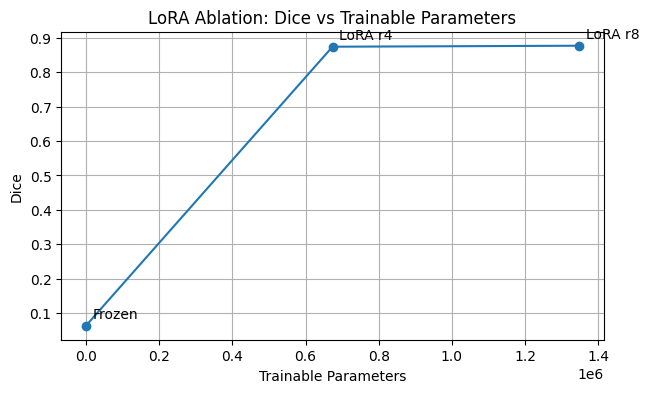

Saved: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_dice_vs_parameters.png


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_summary.csv"
)

df = pd.read_csv(csv_path)

plt.figure(figsize=(7, 4))

plt.plot(
    df["Trainable Parameters"],
    df["Dice"],
    marker="o"
)

for _, row in df.iterrows():
    plt.annotate(
        row["Setting"],
        (
            row["Trainable Parameters"],
            row["Dice"]
        ),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Trainable Parameters")
plt.ylabel("Dice")
plt.title("LoRA Ablation: Dice vs Trainable Parameters")

plt.grid(True)

save_path = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_dice_vs_parameters.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", save_path)

In [66]:
import pandas as pd
from pathlib import Path

csv_path = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_summary.csv"
)

xlsx_path = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_summary.xlsx"
)

df = pd.read_csv(csv_path)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="overall_metrics", index=False)

print("Saved:", xlsx_path)

Saved: /content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/ablation_summary.xlsx


## Final artifact check

In [ ]:
from pathlib import Path

BASE = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation"
)

required_files = [
    BASE / "ablation_summary.csv",
    BASE / "ablation_summary.xlsx",
    BASE / "ablation_complete_summary.json",
    BASE / "ablation_dice_vs_parameters.png",
]

required_runs = [
    BASE / "frozen/a100_frozen_run004/evaluation/run_summary.json",
    BASE / "lora_r4/a100_run001/evaluation/run_summary.json",
    BASE / "lora_r8/a100_r8_run002/evaluation/run_summary.json",
]

print("=== Final artifacts ===")

for path in required_files:
    print(
        path.name,
        "OK" if path.exists() else "MISSING"
    )

print("\n=== Run summaries ===")

for path in required_runs:
    print(
        path,
        "OK" if path.exists() else "MISSING"
    )

## Verification checkpoints

- Patients (train/validation/test): **42 / 9 / 9**.
- All axial slices: **2506 / 537 / 537**; positive slices: **987 / 221 / 232**.
- Test site slices: **Amsterdam 249 / Singapore 144 / Utrecht 144**.
- Batch size **2**, images **[2,3,1024,1024]**, masks **[2,1024,1024]**, boxes **[2,4]**.
- Base model: **MedSAM ViT-B**; all modes load the same base checkpoint.
- Mode-specific counts: asserted against the table at the top, including zero
  trainable parameters/layers for frozen and 80 identical targets for both LoRA ranks.
- Adapter residual remains **original(x) + B(A(x))**, with no alpha/scaling change.
- Rank 4 preserves **673,792** trainable parameters; rank 8 has **1,347,584**.
- Strict checkpoint loading and mode/rank metadata prevent accidental cross-mode use.
- Frozen state hashes include weights and buffers and must stay equal to the base.
- Existing audit, shape, gradient, validation, test and historical-reference outputs
  are retained. Historical-reference deltas are descriptive, not a performance target.

The notebook is delivered with cleared outputs. Syntax, source-preservation and
synthetic control-flow checks are performed during creation; actual GPU training
and data-dependent metrics require the original configured environment and inputs.


## Final Ablation Summary Generation
This section summarizes the completed ablation experiments.
The results are generated from saved run_summary.json files produced by
the frozen, LoRA rank-4, and LoRA rank-8 experiments.

No additional training is performed in this section.

# Final Status

This notebook contains the completed WMH MedSAM LoRA ablation analysis.

Completed configurations:
- Frozen SAM baseline
- LoRA rank-4
- LoRA rank-8

All experiments use fixed patient splits, deterministic settings, frozen backbone verification, and saved evaluation artifacts.

## Reproducibility note

This notebook analyzes completed frozen, LoRA rank-4, and LoRA rank-8 runs.
All reported metrics are loaded from saved evaluation outputs generated during the corresponding runs.
Changing `ABLATION_MODE` and `RUN_TAG` enables independent reruns with new output directories.